X_train shape: (14241, 30, 18)


d:\RUL\DL\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,313 (83.25 KB)

 Trainable params: 21,313 (83.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0397 - val_loss: 0.0089
Epoch 2/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0132 - val_loss: 0.0108
Epoch 3/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0113 - val_loss: 0.0095
Epoch 4/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0100 - val_loss: 0.0113
Epoch 5/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0085 - val_loss: 0.0128
Epoch 6/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0086 - val_loss: 0.0087
Epoch 7/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0062 - val_loss: 0.0083
Epoch 8/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0054 - val_loss: 0.0089
Epoch 9/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0047 - val_loss: 0.0077
Epoch 10/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0042 - val_loss: 0.0084
Epoch 11/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0036 - val_loss: 0.0085
Epoch 12/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step

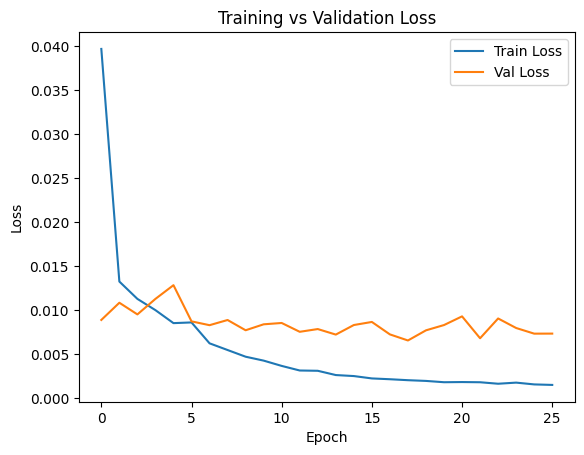

In [1]:
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

# -------------------------
# LOAD DATA
# -------------------------
X_train = np.load("../data/processed/X_train.npy")
y_train = np.load("../data/processed/y_train.npy")

X_val = np.load("../data/processed/X_val.npy")
y_val = np.load("../data/processed/y_val.npy")

print("X_train shape:", X_train.shape)
y_train = y_train/ 125.0
y_val = y_val / 125.0
# -------------------------
# BUILD MODEL
# -------------------------
model_dense = Sequential([
    LSTM(64, input_shape=(X_train.shape[1],X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model_dense.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

model_dense.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model_dense.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

y_train_pred = model_dense.predict(X_train)*125
y_val_pred = model_dense.predict(X_val)*125

y_train_actual = y_train * 125  # ← denormalize the actuals too
y_val_actual = y_val * 125

train_rmse = math.sqrt(mean_squared_error(y_train_actual, y_train_pred))
val_rmse = math.sqrt(mean_squared_error(y_val_actual, y_val_pred))

print("\n=== LSTM RESULTS ===")
print("Train RMSE:", train_rmse)
print("Val RMSE:", val_rmse)


plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [2]:
# -------------------------
# LOAD TEST DATA
# -------------------------
X_test = np.load("../data/processed/X_test_final.npy")
rul_test = np.load("../data/processed/rul_test.npy")

# -------------------------
# PREDICT
# -------------------------
y_test_pred = model_dense.predict(X_test).flatten()

# -------------------------
# RMSE
# -------------------------
y_test_pred = y_test_pred * 125.0
test_rmse = math.sqrt(mean_squared_error(rul_test, y_test_pred))

print("\n=== TEST RESULTS ===")
print("Test RMSE:", test_rmse)

# -------------------------
# SAMPLE PREDICTIONS
# -------------------------
for i in range(10):
    print(
        f"Actual: {rul_test[i]} | "
        f"Predicted: {round(y_test_pred[i], 2)}"
    )

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

=== TEST RESULTS ===
Test RMSE: 30.56346855891135
Actual: [112.] | Predicted: 125.13999938964844
Actual: [98.] | Predicted: 126.30000305175781
Actual: [69.] | Predicted: 66.9800033569336
Actual: [82.] | Predicted: 83.3499984741211
Actual: [91.] | Predicted: 82.01000213623047
Actual: [93.] | Predicted: 86.08999633789062
Actual: [91.] | Predicted: 63.63999938964844
Actual: [95.] | Predicted: 38.400001525878906
Actual: [111.] | Predicted: 126.33999633789062
Actual: [96.] | Predicted: 24.190000534057617
